# Does the *zero-lag* EMA actually buy you anything? ⚡
### A moving average that promises to kill its own lag — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Removing_lag_buys_edge%3F: Busted](https://img.shields.io/badge/Removing_lag_buys_edge%3F-Busted-8b949e?style=flat-square)

Every moving average lags price: it's an average of the past, so it trails behind. John Ehlers' **zero-lag EMA** (ZLEMA) is a clever fix — instead of smoothing the price, it smooths `price + (price − price-a-few-bars-ago)`, which nudges the input *forward* so the line catches up. The pitch is irresistible: a trend filter with **no lag** should get you into trends sooner and out sooner, beating a plain old EMA of the same length.

It *looks* great on a chart — the ZLEMA hugs price more tightly. But 'hugs price tighter' and 'makes you money' are two very different things. So we did the only fair test: encode the rule **mechanically** (long while price is above the ZLEMA), fire it thousands of times across five big indices over 21 years, and race it against two honest baselines — **buying on random days**, and the **plain EMA it claims to beat.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from zlema import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real ZLEMA cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 2811, 'length': 20, 'step': 5, 'fp_spy': '4cb5244f3990', 'h5': (5, 2806, 15.1, 56, 3.58, 24.7, -9.6, 19.4, -4.2, 13.1, -1.37, 0.17), 'h10': (10, 2806, 44.8, 62, 6.53, 54.3, -9.5, 43.9, 0.9, 42.8, -0.99, 0.323), 'h20': (20, 2799, 96.0, 64, 8.09, 117.2, -21.2, 80.6, 15.4, 94.0, -1.57, 0.116), 'h60': (60, 2779, 265.0, 68, 7.93, 279.5, -14.6, 250.7, 14.2, 263.0, -0.63, 0.529), 'per': [('SPY', 566, 88.0, 3.82, 115.6, -27.5, 7.3), ('QQQ', 568, 122.1, 4.1, 171.8, -49.7, 4.0), ('IWM', 554, 90.4, 2.94, 106.2, -15.8, 39.3), ('DIA', 558, 80.8, 3.66, 104.3, -23.6, 18.6), ('GLD', 565, 98.4, 3.57, 87.5, 11.0, 7.7)], 'placebo': (88.0, 0.363, 500), 'upcross': (602, 72.6, 68, 2.48), 'syn': [(0.0, 403, 0.3, 47, 0.01, 18.3, 0.55), (2.0, 565, 5676.8, 62, 4.94, 9589.1, 7.52)]}


real ZLEMA cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when price is above the **zero-lag EMA**, do I make money? | **Yes — but only because the market goes up.** The win-rate is ~60% and the returns look great. |
| Is that *the ZLEMA's* doing? | **No.** Buy on **random days** instead and you do **just as well or better** — the ZLEMA filter is *worse* than a coin-flip entry at every horizon. |
| Does removing the lag beat a plain EMA? | **No.** Head-to-head, the de-lagged line and the boring EMA finish in a dead heat (a few bps apart, sign flipping). |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the market's upward drift, dressed up as a fancy filter. The 'zero lag' is cosmetic. |

> The zero-lag EMA is a nicer-looking line. As a *forecast* — 'less lag = timelier trades' — it's a **mirage**: all of the apparent edge is the market's climb, and the de-lag adds nothing the plain EMA didn't already give you.

## 1 · The claim

> *"A normal EMA lags price by about half its length. The **zero-lag EMA** smooths a de-lagged input — `price + (price − price[lag])` — so it tracks price with (almost) no lag. A timelier line means timelier signals: go long while price is above the ZLEMA and you'll catch trends earlier and beat a plain EMA."*

This is **John Ehlers'** zero-lag / 'instantaneous trendline' idea (early 2000s), part of a whole family of low-lag averages (DEMA, TEMA, KAMA…). It's built into TradingView, MetaTrader and every charting suite. So: does killing the lag actually buy you an edge?

## 2 · So what?

If a de-lagged line genuinely *forecast* better, it would be a free lunch: the same trend filter, only earlier, for the price of one subtraction. That's the dream the indicator sells.

But there are two traps. **(a)** It runs on stock indices that drift **up** over time, so *any* 'be long in an uptrend' rule looks profitable — that's the market, not the filter. **(b)** 'Less lag' isn't free: subtracting the lag is a high-pass tweak that **amplifies noise**, so the zero-lag line *overshoots* and whipsaws. To separate the **tool** from the **tide** we have to (i) compare to buying on **random days**, and (ii) put it head-to-head against the **plain EMA** it claims to beat. We do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Build the zero-lag EMA mechanically.** Length 20, the de-lag uses a fixed lookback — only past prices, nothing from the future.
2. **Trade the lore.** While price is above the ZLEMA, we're long; we sample that state every 5 days and measure the return over the next **5 / 10 / 20 / 60 days** (entering at the next close — one honest lag).
3. **The drift baseline.** Do the exact same hold on **random days**. If the ZLEMA matters, it must beat random.
4. **The head-to-head.** Run the *identical* rule on a **plain EMA** of the same length. If the de-lag buys anything, the ZLEMA must beat the EMA. *If it doesn't, the 'zero lag' is decoration* — announced before we look.

## 4 · The teardown — let's actually look

First, what does the zero-lag line even look like next to a plain EMA? Here's SPY with both — notice the ZLEMA (green) hugs price more tightly, but also jitters more.

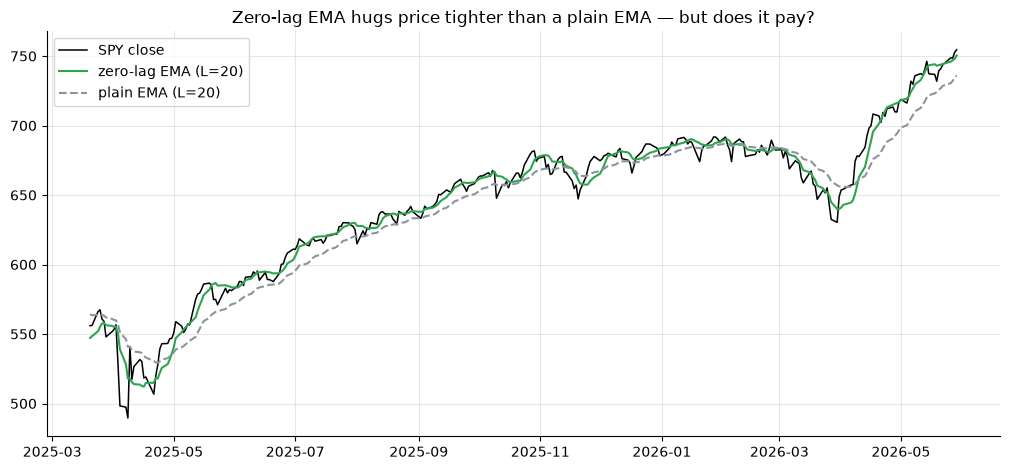

In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']; seg = cl.iloc[-300:]
    z = st.zlema(cl, R['length']); e = st.ema(cl, R['length'])
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.1, label='SPY close')
    ax.plot(seg.index, z.reindex(seg.index), c=GREEN, lw=1.5, label='zero-lag EMA (L=20)')
    ax.plot(seg.index, e.reindex(seg.index), c=GREY, lw=1.5, ls='--', label='plain EMA (L=20)')
    ax.set_title('Zero-lag EMA hugs price tighter than a plain EMA — but does it pay?')
    ax.legend(loc='upper left'); plt.tight_layout(); plt.show()
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The ZLEMA tracks price more closely — *as a drawing*. The question is whether being above it predicts anything. **Let's race the ZLEMA filter against random entries** at four horizons. Green = long while above the ZLEMA; grey = buy on random days.

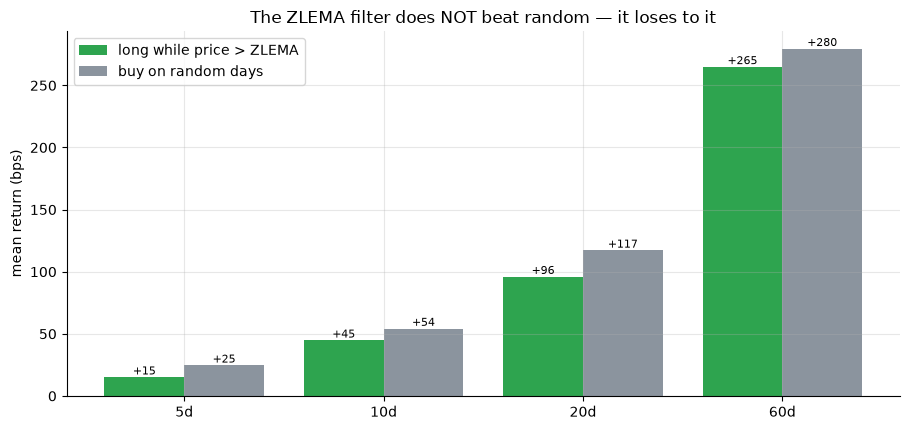

zlema: [15, 45, 96, 265]
random: [25, 54, 117, 280]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    zlema, rnd = [], []
    for h in hs:
        zz, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.zlema_entries(c, length=R['length'])
            re = st.random_entries(c, max(len(e),50), length=R['length'], seed=7)
            zz.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        zlema.append(np.concatenate(zz).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    zlema = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, zlema, .4, color=GREEN, label='long while price > ZLEMA')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(zlema,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The ZLEMA filter does NOT beat random — it loses to it'); ax.legend()
plt.tight_layout(); plt.show()
print('zlema:', [round(v) for v in zlema]); print('random:', [round(v) for v in rnd])

There's the whole story. The ZLEMA filter makes money in absolute terms (**+96 bps** over 20 days) — but **random entries make more** (**+117 bps**). At *every* horizon the famous zero-lag line is *worse* than throwing darts. The apparent profit was **the market's upward drift**, not the filter.

**The decisive test for *this* indicator.** ZLEMA's specific promise is 'better than a plain EMA'. So put them head-to-head — the *same* rule, one on the de-lagged line, one on the boring EMA. If removing the lag buys anything, the green bars beat the grey ones.

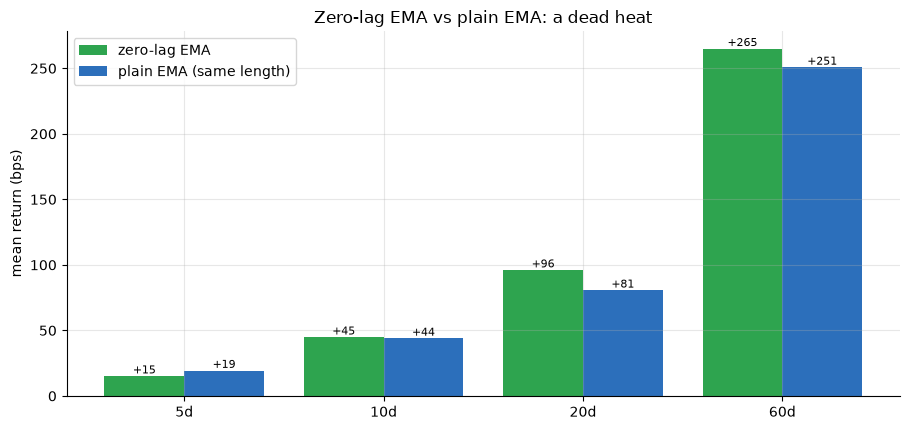

zlema-minus-ema (bps): [-4, 1, 15, 14]


In [4]:
if HAVE_REAL:
    zz, ee = [], []
    for h in hs:
        z1, e1 = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            z1.append(st.forward_returns(c, st.zlema_entries(c, length=R['length']), h))
            e1.append(st.forward_returns(c, st.ema_entries(c, length=R['length']), h))
        zz.append(np.concatenate(z1).mean()*1e4); ee.append(np.concatenate(e1).mean()*1e4)
else:
    zz = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    ee = [R['h5'][7], R['h10'][7], R['h20'][7], R['h60'][7]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, zz, .4, color=GREEN, label='zero-lag EMA')
ax.bar(x+.2, ee, .4, color='#2c6fbb', label='plain EMA (same length)')
for i,(a,bb) in enumerate(zip(zz,ee)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('Zero-lag EMA vs plain EMA: a dead heat'); ax.legend()
plt.tight_layout(); plt.show()
print('zlema-minus-ema (bps):', [round(a-b) for a,b in zip(zz,ee)])

A dead heat. ZLEMA minus the plain EMA is **-4 / +1 / +15 / +14 bps** across the four horizons — a few basis points, sign flipping, nothing you could trade. Removing the lag changed the *picture*, not the *payoff*. The 'zero lag' was decoration.

## 5 · The verdict

- **Signal — None.** The ZLEMA filter does **not** beat buying on random days (it's *worse* at every horizon). The big absolute returns are the market's drift.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **"Removing the lag buys edge"? — Busted.** Head-to-head with a plain EMA it's a dead heat, and scrambling the de-lag changes nothing. The 'zero lag' is cosmetic.

## 6 · Could you actually trade it?

There's nothing here to trade. The ZLEMA filter's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. And its one job, to beat a plain EMA, it fails: same payoff, more whipsaws. The de-lag adds noise, not edge. As a forecasting tool it doesn't pay; as a nicer-looking line, it was never a strategy.

## 7 · Going further 🚪

- **The whippy cross.** The *upcross* version (buy the moment price crosses above the ZLEMA) is even worse — the de-lag overshoots so the cross fires near tops. The quants notebook shows it banks *less* of a real planted trend than the steady filter.
- **The low-lag family.** DEMA, TEMA, KAMA, HMA are the same de-lag idea in different clothes — the desk's sibling studies find the same thing: nicer line, same drift.
- **A real positive control.** The quants notebook plants a *genuine* persistent trend into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there'), and that the **plain EMA banks more**.

*Think zero-lag forecasts? Show the ZLEMA filter beating random entries **and** the plain EMA at **t ≥ 2** on a real tape — then we'll talk.*